## ライブラリのインポート

In [1]:
import numpy as np

import plotly.graph_objects as go
from dataclasses import dataclass

## Nodeクラスの作成

In [2]:
@dataclass
class Node:
    num: int
    x :float
    y :float

## Elementクラスの作成

In [3]:
class Element:

    def __init__(self, num: int, node1: Node, node2: Node, node3: Node, is_up:bool, is_low:bool):
        self.num = num
        self.node1 = node1
        self.node2 = node2
        self.node3 = node3
        self.is_up = is_up
        self.is_low = is_low
        self.node_nums = [node1.num, node2.num, node3.num] 
        self.B_matrix = self.calculate_B_matrix()
        self.D_matrix = self.set_D_matrix()
        self.K_matrix = self.calculate_K_matrix()
        self.Kw_matrix = self.calculate_Kw_matrix()
        

    def calculate_B_matrix(self):
        B_matrix = np.zeros((3,6))
        B_matrix[0][0] = self.node2.y - self.node3.y                    
        B_matrix[0][2] = self.node3.y - self.node1.y                    
        B_matrix[0][4] = self.node1.y - self.node2.y                    
        B_matrix[1][1] = self.node3.x - self.node2.x                    
        B_matrix[1][3] = self.node1.x - self.node3.x                    
        B_matrix[1][5] = self.node2.x - self.node1.x                    
        B_matrix[2][0] = self.node3.x - self.node2.x                    
        B_matrix[2][1] = self.node2.y - self.node3.y                    
        B_matrix[2][2] = self.node1.x - self.node3.x                    
        B_matrix[2][3] = self.node3.y - self.node1.y                    
        B_matrix[2][4] = self.node2.x - self.node1.x                    
        B_matrix[2][5] = self.node1.y - self.node2.y
        return B_matrix

    def set_D_matrix(self):
        return np.array(
            [[1.0, 0.5, 0.0],
             [0.5, 1.0, 0.0],
             [0.0, 0.0, 1.0]]
        )

    def calculate_K_matrix(self):
        return self.B_matrix.T @ self.D_matrix.T @ self.B_matrix

    def calculate_Kw_matrix(self):
        Kw_matrix = np.zeros((60,60))
        for i in range(self.B_matrix.shape[1]):
            idx_i = self.node_nums[int(i/2)]
            k = idx_i * 2 +(i % 2)
            for j in range(self.B_matrix.shape[1]):
                idx_j = self.node_nums[int(j/2)]
                l = idx_j * 2 +(j % 2)
                Kw_matrix[k][l] = self.K_matrix[i][j]
        return Kw_matrix

## Nodeインスタンスの作成

In [4]:
node_lst = []

for i in range(3):
    for j in range(10):
        node = Node(num=10*i+j, x=j, y=i)
        node_lst.append(node)

print(len(node_lst))

30


## Nodeの表示

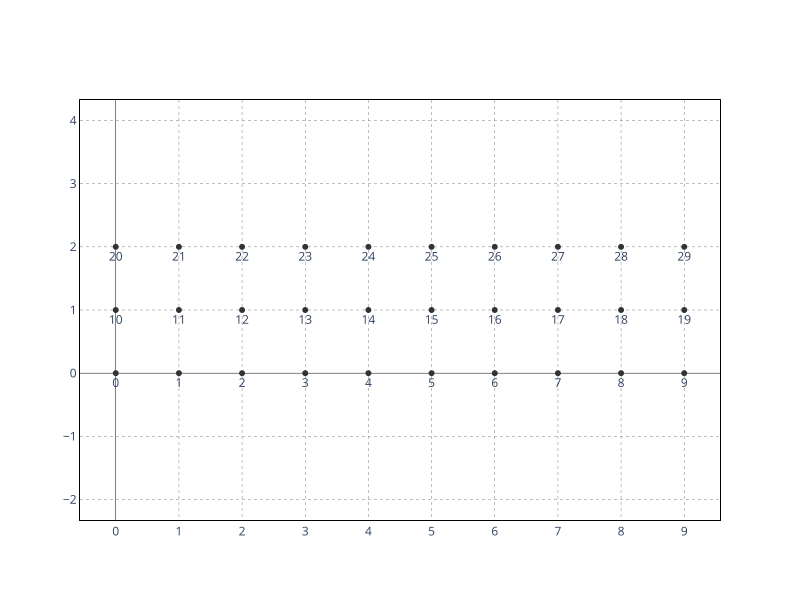

In [5]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[node.x for node in node_lst],
    y=[node.y for node in node_lst],
    text=[f"{node.num}" for node in node_lst],
    mode="markers+text",
    showlegend=False,
    marker={"color":"#333"},
    textposition="bottom center"))
fig.update_layout(
    width=800,
    height=600,
    plot_bgcolor="white",
)
fig.update_yaxes(
    scaleanchor="x",  # x 軸に基づいて縦横比固定
    scaleratio=1,
    linecolor='black', 
    gridcolor='gray',
    griddash='dot',
    gridwidth=0.5,
    mirror=True,
    zeroline=True,
    zerolinecolor='black',
    zerolinewidth=0.5,
)
fig.update_xaxes(
    linecolor="black",
    gridcolor="gray",
    griddash='dot',
    gridwidth=0.5,
    mirror=True,
    zeroline=True,
    zerolinecolor='black',
    zerolinewidth=0.5,
    dtick=1.0,
)
fig.show(renderer="svg")

## Elementインスタンスの作成

In [6]:
element_lst = []

for j in range(2):
    for i in range(18):
        if i < 9:
            element = Element(
                j * 18 + i, 
                node_lst[(i+0)+(j*10)],
                node_lst[(i+1)+(j*10)],
                node_lst[(i+11)+(j*10)],
                is_up=(i < 9),
                is_low=not (i < 9)
                
            )
        else:
            element = Element(
                j * 18 + i, 
                node_lst[(i%9)+0+(j*10)],
                node_lst[(i%9)+11+(j*10)],
                node_lst[(i%9)+10+(j*10)],
                is_low=(i % 9 < 9),
                is_up=not (i % 9 < 9),
            )
        element_lst.append(element)

for element in element_lst:
    print(element.num, element.node_nums)

0 [0, 1, 11]
1 [1, 2, 12]
2 [2, 3, 13]
3 [3, 4, 14]
4 [4, 5, 15]
5 [5, 6, 16]
6 [6, 7, 17]
7 [7, 8, 18]
8 [8, 9, 19]
9 [0, 11, 10]
10 [1, 12, 11]
11 [2, 13, 12]
12 [3, 14, 13]
13 [4, 15, 14]
14 [5, 16, 15]
15 [6, 17, 16]
16 [7, 18, 17]
17 [8, 19, 18]
18 [10, 11, 21]
19 [11, 12, 22]
20 [12, 13, 23]
21 [13, 14, 24]
22 [14, 15, 25]
23 [15, 16, 26]
24 [16, 17, 27]
25 [17, 18, 28]
26 [18, 19, 29]
27 [10, 21, 20]
28 [11, 22, 21]
29 [12, 23, 22]
30 [13, 24, 23]
31 [14, 25, 24]
32 [15, 26, 25]
33 [16, 27, 26]
34 [17, 28, 27]
35 [18, 29, 28]


## Elementの可視化

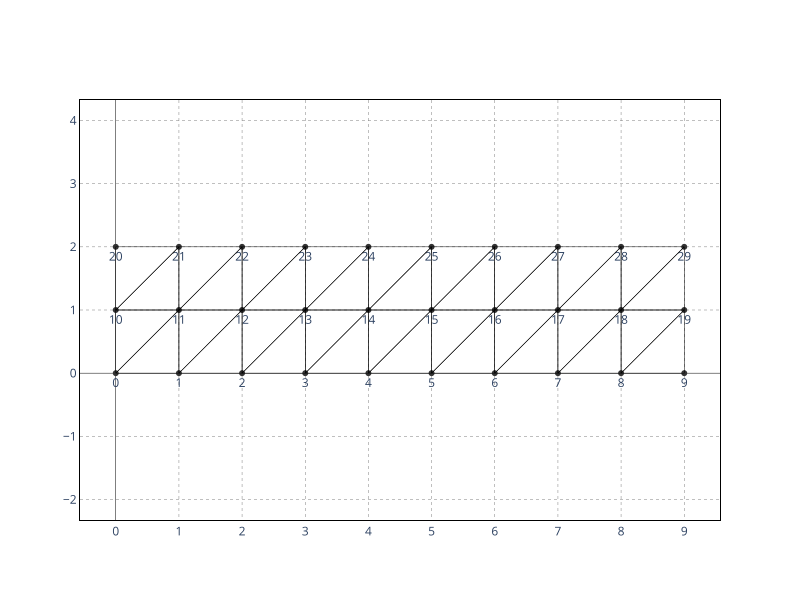

In [7]:
scatter_lst = []
line_width=0.5
for element in element_lst:
    scatter_lst.append(
        go.Scatter(
            x=[element.node1.x, element.node2.x, element.node3.x, element.node1.x],
            y=[element.node1.y, element.node2.y, element.node3.y, element.node1.y],
            showlegend=False,
            name=f"element{element.num}",
            mode="lines", 
            # fill="toself",
            line=dict(color="black" if element.is_up else "black", width=line_width)
        ))
fig.add_traces(scatter_lst)
fig.show(renderer="svg")

## 大域剛性行列の作成

In [8]:
K_whole = np.zeros((60,60))
for element in element_lst:
    K_whole += element.Kw_matrix
K_whole.shape

(60, 60)

## 荷重ベクトルの作成

In [9]:
f = np.zeros((60, 1))
f[-1] = -0.01
f.shape

(60, 1)

##　境界条件の設定

In [10]:
c = np.zeros((60,1))
c[0] = 1
c[1] = 1
c[20] = 1
c[21] = 1
c[40] = 1
c[41] = 1
mask = (c[:,0] != 1)

## 変位ベクトルの計算

In [11]:
u_base = np.linalg.inv(K_whole[mask, :][:,mask]) @ f[mask, :] 

# 新しい (60,1) ベクトルを作る
u = np.zeros((60,1))
u[mask, 0] = (u_base[:,0])
u.shape

(60, 1)

## 荷重を加えた後の座標を求める

In [12]:
new_node_lst = []
u_reshape = u.reshape((-1, 2))

for i in range(3):
    for j in range(10):
        new_node = Node(
            num=10*i+j,
            x=j+u_reshape[10*i+j][0],
            y=i+u_reshape[10*i+j][1],
        )
        new_node_lst.append(new_node)

len(new_node_lst)

30

In [13]:
new_element_lst = []

for j in range(2):
    for i in range(18):
        if i < 9:
            new_element = Element(
                j * 18 + i, 
                new_node_lst[(i+0)+(j*10)],
                new_node_lst[(i+1)+(j*10)],
                new_node_lst[(i+11)+(j*10)],
                is_up=(i < 9),
                is_low=not (i < 9)
                
            )
        else:
            new_element = Element(
                j * 18 + i, 
                new_node_lst[(i%9)+0+(j*10)],
                new_node_lst[(i%9)+11+(j*10)],
                new_node_lst[(i%9)+10+(j*10)],
                is_low=(i % 9 < 9),
                is_up=not (i % 9 < 9),
            )
        new_element_lst.append(new_element)

for element in new_element_lst:
    print(element.num, element.node_nums)

0 [0, 1, 11]
1 [1, 2, 12]
2 [2, 3, 13]
3 [3, 4, 14]
4 [4, 5, 15]
5 [5, 6, 16]
6 [6, 7, 17]
7 [7, 8, 18]
8 [8, 9, 19]
9 [0, 11, 10]
10 [1, 12, 11]
11 [2, 13, 12]
12 [3, 14, 13]
13 [4, 15, 14]
14 [5, 16, 15]
15 [6, 17, 16]
16 [7, 18, 17]
17 [8, 19, 18]
18 [10, 11, 21]
19 [11, 12, 22]
20 [12, 13, 23]
21 [13, 14, 24]
22 [14, 15, 25]
23 [15, 16, 26]
24 [16, 17, 27]
25 [17, 18, 28]
26 [18, 19, 29]
27 [10, 21, 20]
28 [11, 22, 21]
29 [12, 23, 22]
30 [13, 24, 23]
31 [14, 25, 24]
32 [15, 26, 25]
33 [16, 27, 26]
34 [17, 28, 27]
35 [18, 29, 28]


## 可視化

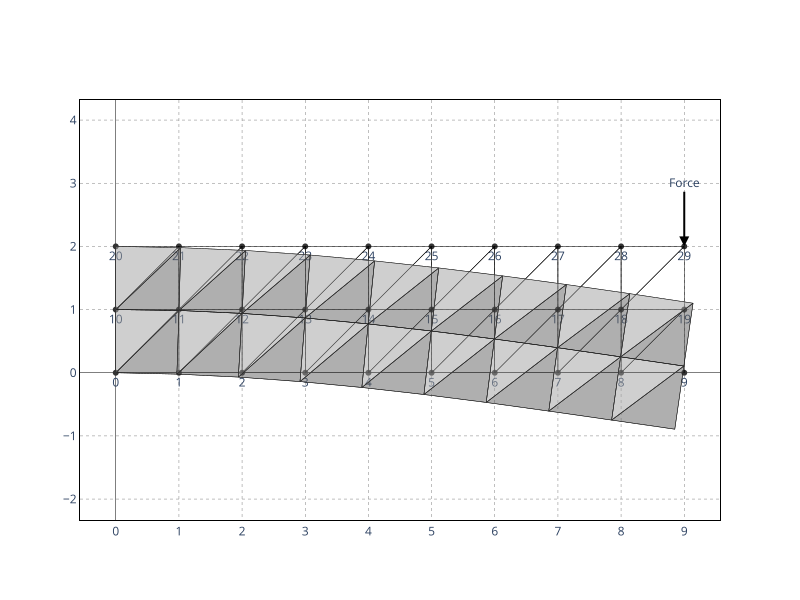

In [14]:
new_scatter_lst = []
line_width=0.5
for new_element in new_element_lst:
    new_scatter_lst.append(
        go.Scatter(
            x=[new_element.node1.x, new_element.node2.x, new_element.node3.x, new_element.node1.x],
            y=[new_element.node1.y, new_element.node2.y, new_element.node3.y, new_element.node1.y],
            showlegend=False,
            name=f"new_element{new_element.num}",
            mode="lines", 
            fill="toself",
            line=dict(color="#606060" if new_element.is_up else "#a0a0a0", width=line_width)
        ))
    new_scatter_lst.append(
        go.Scatter(
            x=[new_element.node1.x, new_element.node2.x, new_element.node3.x, new_element.node1.x],
            y=[new_element.node1.y, new_element.node2.y, new_element.node3.y, new_element.node1.y],
            showlegend=False,
            name=f"new_element{new_element.num}",
            mode="lines", 
            line=dict(color="black", width=line_width)
        ))
    
fig.add_traces(new_scatter_lst)
fig.add_annotation({"x":9, "y":2, "xref":"x", "yref":"y", "ax":9, "ay":3, "axref":"x", "ayref":"y",
    "showarrow":True, "arrowhead":2, "arrowsize":1, "arrowwidth":2, "arrowcolor":"black", "text":"Force"})
fig.show(renderer="svg")